# Hacker News SQL Analytics

**Dataset:** `bigquery-public-data.hacker_news.full` (48.5M rows)  
**Tool:** BigQuery + Python   

Extract platform-level insights about content engagement, creator behaviour, and growth patterns


In [13]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

project_id = "hacker-news-sql-analytics"
client = bigquery.Client(project=project_id)

In [14]:
import pandas as pd

q1 = """
WITH new_t AS (
  SELECT
    PERCENT_RANK() OVER (ORDER BY score DESC) AS percentile_rank,
    SUM(score) OVER (ORDER BY score DESC) AS running_sum,
    SUM(score) OVER () AS total_score
  FROM `bigquery-public-data.hacker_news.full`
  WHERE type = 'story'
    AND score IS NOT NULL
)
SELECT '1%' AS cutoff,
       MAX(running_sum) / MAX(total_score) AS pct_of_total_engagement
FROM new_t
WHERE percentile_rank <= 0.01

UNION ALL

SELECT '5%' AS cutoff,
       MAX(running_sum) / MAX(total_score) AS pct_of_total_engagement
FROM new_t
WHERE percentile_rank <= 0.05
"""

q2 = """
WITH post_gaps AS (
  SELECT
    `by`,
    score,
    timestamp,
    LAG(timestamp, 1) OVER (PARTITION BY `by` ORDER BY timestamp) AS prev_timestamp
  FROM `bigquery-public-data.hacker_news.full`
  WHERE type = 'story'
    AND score IS NOT NULL
    AND `by` IS NOT NULL
),
average AS (
  SELECT
    AVG(TIMESTAMP_DIFF(timestamp, prev_timestamp, DAY)) AS avg_diff,
    AVG(score) AS avg_score,
    `by`,
    COUNT(*) AS total_posts
  FROM post_gaps
  GROUP BY `by`
)
SELECT `by`, avg_diff, avg_score, total_posts
FROM average
WHERE total_posts >= 10
ORDER BY avg_score DESC
"""

q3 = """
WITH first_calc AS (
  SELECT EXTRACT(YEAR FROM timestamp) AS year,
         EXTRACT(MONTH FROM timestamp) AS month,
         COUNT(*) AS monthly_count
  FROM `bigquery-public-data.hacker_news.full`
  WHERE type = 'story' AND timestamp IS NOT NULL
  GROUP BY year, month
),
rolling AS (
  SELECT monthly_count,
         LAG(monthly_count, 1) OVER (ORDER BY year, month) AS prev_count,
         SUM(monthly_count) OVER (ORDER BY year, month) AS roll_count,
         year,
         month
  FROM first_calc
)
SELECT prev_count,
       year,
       month,
       monthly_count,
       (monthly_count - prev_count) / prev_count * 100 AS mth_change,
       roll_count
FROM rolling
ORDER BY year, month
"""

q4 = """
WITH engagement AS (
  SELECT
    `by`,
    SUM(CASE WHEN type = 'story' THEN 1 ELSE 0 END) AS stories_posted,
    SUM(CASE WHEN type = 'comment' THEN 1 ELSE 0 END) AS comments_made,
    SUM(score) AS total_score,
    AVG(score) AS avg_score
  FROM `bigquery-public-data.hacker_news.full`
  WHERE `by` IS NOT NULL
  GROUP BY `by`
  HAVING SUM(CASE WHEN type = 'story' THEN 1 ELSE 0 END) >= 10
),
ranked AS (
  SELECT
    `by`,
    stories_posted,
    comments_made,
    total_score,
    avg_score,
    DENSE_RANK() OVER (ORDER BY total_score DESC) AS rank
  FROM engagement
)
SELECT * FROM ranked WHERE rank <= 25 ORDER BY rank
"""

q5 = """
WITH author_stats AS (
  SELECT
    `by`,
    AVG(score) AS avg_score
  FROM `bigquery-public-data.hacker_news.full`
  WHERE type = 'story' AND score IS NOT NULL
  GROUP BY `by`
  HAVING COUNT(*) >= 10
),
story_scores AS (
  SELECT
    `by`,
    id,
    score,
    title
  FROM `bigquery-public-data.hacker_news.full`
  WHERE type = 'story' AND score IS NOT NULL
)
SELECT
  s.`by`,
  s.id,
  s.title,
  s.score,
  a.avg_score,
  s.score / a.avg_score AS score_ratio,
  CASE
    WHEN s.score / a.avg_score >= 2 THEN 'outperformed'
    WHEN s.score / a.avg_score < 0.5 THEN 'underperformed'
    ELSE 'normal'
  END AS performance_label
FROM story_scores s
JOIN author_stats a ON s.`by` = a.`by`
ORDER BY score_ratio DESC
"""

df1 = client.query(q1).to_dataframe()
print("Q1 done:", df1.shape)

df2 = client.query(q2).to_dataframe()
print("Q2 done:", df2.shape)

df3 = client.query(q3).to_dataframe()
print("Q3 done:", df3.shape)

df4 = client.query(q4).to_dataframe()
print("Q4 done:", df4.shape)

df5 = client.query(q5).to_dataframe()
print("Q5 done:", df5.shape)


Q1 done: (2, 2)
Q2 done: (75009, 4)
Q3 done: (235, 6)
Q4 done: (25, 6)
Q5 done: (4847762, 7)


## Query 1: Engagement Concentration

**Question:** How concentrated is engagement across stories on Hacker News?

**Approach:** Used `PERCENT_RANK()` to segment stories into tiers, then computed each tier's share of total platform score using cumulative `SUM() OVER()`.

**Finding:** A small fraction of stories captures a disproportionately large share of total engagement, suggesting a highly skewed distribution where a minority of content dominates platform attention.

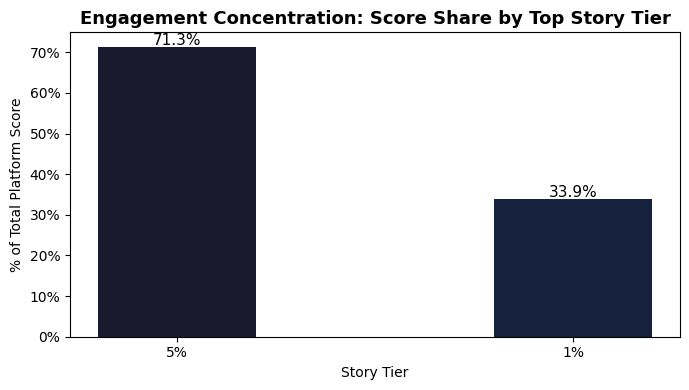

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df1['cutoff'], df1['pct_of_total_engagement'] * 100,
       color=['#1a1a2e', '#16213e'], width=0.4)
ax.set_title('Engagement Concentration: Score Share by Top Story Tier',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Story Tier')
ax.set_ylabel('% of Total Platform Score')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for i, row in df1.iterrows():
    ax.text(i, row['pct_of_total_engagement'] * 100 + 0.5,
            f"{row['pct_of_total_engagement']*100:.1f}%",
            ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('q1_engagement_concentration.png', dpi=150)
plt.show()

## Query 2: Creator Cadence vs Performance

**Question:** Do authors who post more regularly tend to score higher or lower?

**Approach:** Used `LAG()` to compute the gap between consecutive posts per author, then aggregated to get each author's average posting interval and average score. Filtered to authors with 10+ stories.

**Finding:** There is no strong linear relationship between posting frequency and average score, suggesting that posting cadence alone does not predict content quality, content fit may matter more than volume.

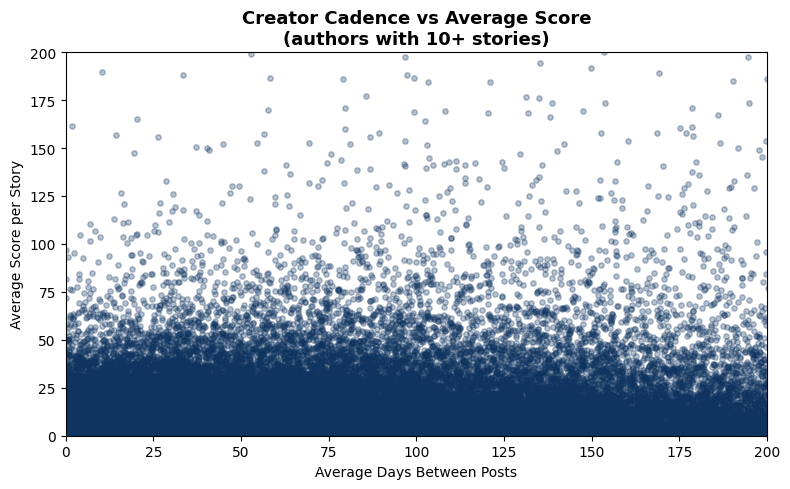

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df2['avg_diff'], df2['avg_score'],
           alpha=0.3, s=15, color='#0f3460')
ax.set_title('Creator Cadence vs Average Score\n(authors with 10+ stories)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Days Between Posts')
ax.set_ylabel('Average Score per Story')
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)
plt.tight_layout()
plt.savefig('q2_cadence_vs_performance.png', dpi=150)
plt.show()

## Query 3: Platform Growth Rate

**Question:** How has story posting activity changed over time on Hacker News?

**Approach:** Extracted year and month from timestamps, computed monthly story counts, then used `LAG()` for month-on-month % change and `SUM() OVER()` for cumulative volume.

**Data Quality Note:** November 2006 and January 2007 are missing from the dataset entirely. Analysis is most reliable from mid-2007 onwards. This highlights an important real-world consideration: window functions assume consecutive ordering, and sparse early data can produce statistically valid but contextually misleading results.

**Finding:** Platform posting volume has grown consistently from 2007 through
to the present, with monthly postings continuing to rise into 2024-2025.

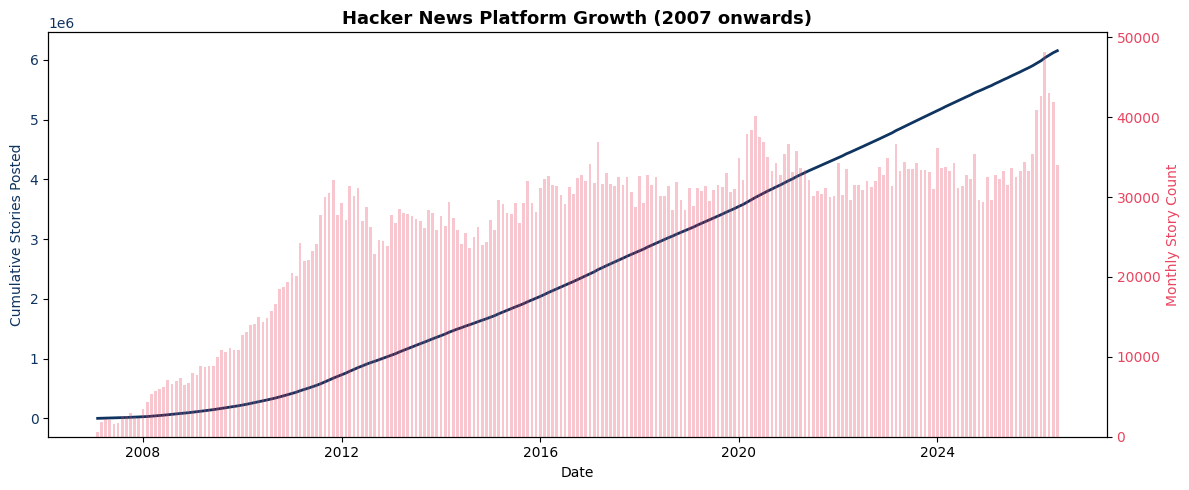

In [17]:
df3_clean = df3.dropna(subset=['mth_change'])
df3_clean = df3_clean[df3_clean['year'] >= 2007].copy()
df3_clean['date'] = pd.to_datetime(
    df3_clean[['year', 'month']].assign(day=1))

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df3_clean['date'], df3_clean['roll_count'],
         color='#0f3460', linewidth=2, label='Cumulative Stories')
ax1.set_ylabel('Cumulative Stories Posted', color='#0f3460')
ax1.tick_params(axis='y', labelcolor='#0f3460')

ax2 = ax1.twinx()
ax2.bar(df3_clean['date'], df3_clean['monthly_count'],
        alpha=0.3, color='#e94560', width=20, label='Monthly Count')
ax2.set_ylabel('Monthly Story Count', color='#e94560')
ax2.tick_params(axis='y', labelcolor='#e94560')

ax1.set_title('Hacker News Platform Growth (2007 onwards)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Date')
plt.tight_layout()
plt.savefig('q3_platform_growth.png', dpi=150)
plt.show()

## Query 4: Most Engaged Authors

**Question:** Which authors have accumulated the highest total score on the platform?

**Approach:** Aggregated total score, story count, and comment count per author using `SUM(CASE WHEN ...)`, then ranked authors by total score using `DENSE_RANK()`. Filtered to authors with at least 10 stories to exclude low-volume outliers.

**Finding:** The top authors by total score are not necessarily the most
prolific posters. Some accumulate high total scores through fewer
submissions, suggesting that story volume alone does not determine an
author's total score.

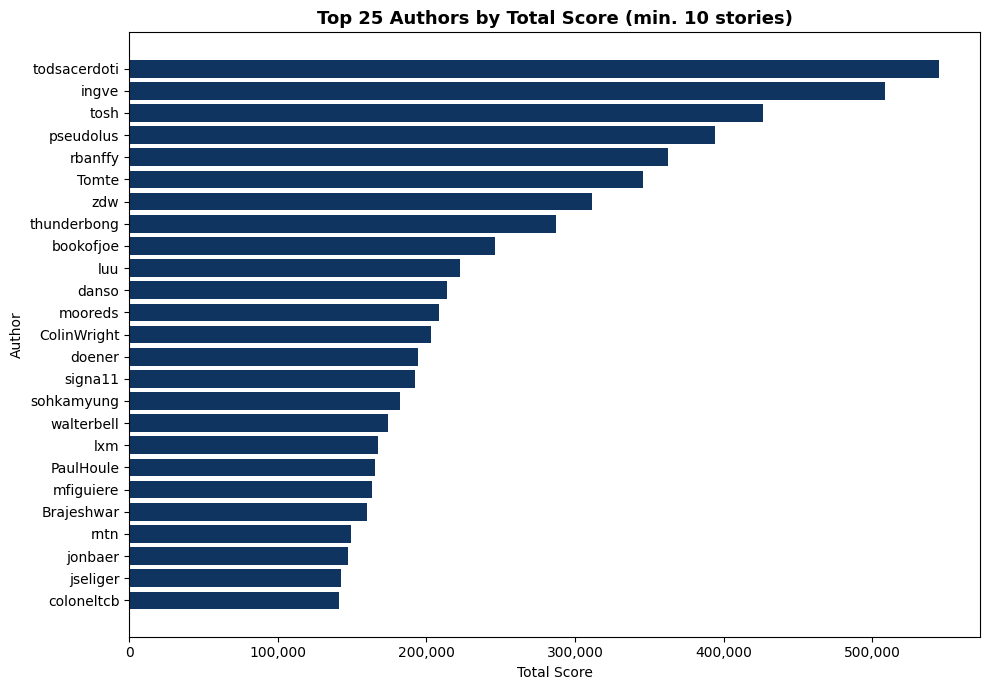

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(df4['by'], df4['total_score'], color='#0f3460')
ax.invert_yaxis()
ax.set_title('Top 25 Authors by Total Score (min. 10 stories)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Score')
ax.set_ylabel('Author')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('q4_top_authors.png', dpi=150)
plt.show()

## Query 5: Score Consistency vs Author Baseline

**Question:** Which stories significantly over- or underperformed relative to their author's typical score?

**Approach:** Computed each author's average score across their stories (min. 10 stories), then joined back to individual story scores to calculate a `score_ratio`. Stories scoring 2x or more above their author's baseline are labelled `outperformed`; below 0.5x are labelled `underperformed`.

**Note:** These labels are relative to each author's own baseline, not absolute platform thresholds.

**Finding:** The majority of individual stories (3.1M out of 4.8M) score
below their author's average baseline. Stories that outperform that baseline
by 2x or more are rare, accounting for only ~420K stories.

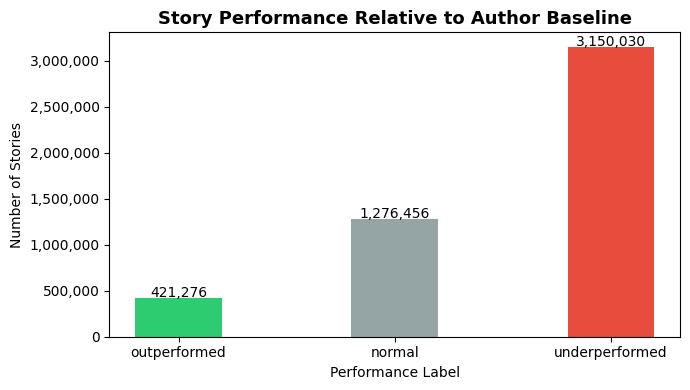

In [19]:
label_counts = df5['performance_label'].value_counts().reindex(
    ['outperformed', 'normal', 'underperformed'])
colors = ['#2ecc71', '#95a5a6', '#e74c3c']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(label_counts.index, label_counts.values, color=colors, width=0.4)
ax.set_title('Story Performance Relative to Author Baseline',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Performance Label')
ax.set_ylabel('Number of Stories')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
for i, (label, val) in enumerate(label_counts.items()):
    ax.text(i, val + 10000, f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('q5_performance_distribution.png', dpi=150)
plt.show()


## Key Takeaways

Across all five analyses, engagement on Hacker News follows a highly skewed
distribution which is a pattern worth examining for any platform where content competes
for finite user attention.

**Engagement is winner-takes-most:** The top 1% of stories capture 33.9%
of total platform score; the top 5% capture 71.3%. This suggests that
optimising for median content performance may be less impactful than
understanding what drives breakout stories.

**Volume does not predict quality:** No clear relationship emerged between
posting frequency and average score, suggesting that posting cadence alone
may not be a reliable indicator of content performance.

**Platform growth is ongoing:** Monthly story submissions have grown
consistently from 2007 through to the present, with cumulative volume
exceeding 6 million stories.

**A small group of authors accumulates outsized total scores:** The top
25 authors by total score range from ~140,000 to ~540,000 points, with
the leading author (todsacerdoti) scoring nearly 4x the 25th ranked author.

**Underperformance is the norm, outperformance is rare:** The majority of
individual stories score below their author's average baseline. This is
mathematically expected since averages are skewed upward by occasional
high-scoring stories but the scale of underperformance (3.1M stories)
versus outperformance (420K) suggests engagement is heavily concentrated
in a small fraction of each author's output.

**Data quality note:** November 2006 and January 2007 are missing from the
dataset. Analysis is
scoped to mid-2007 onwards where data is reliable. This serves as a reminder
that window functions assume consecutive ordering, sparse early data can produce
statistically valid but contextually misleading results.